
              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0-post0.dev0
 Built: Dec  9 2024 17:34:57

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Aug 01 21:04:45 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Aug 01 21:04:45 Install [Info]: 
    loaded module adex_2expnms_gap_rec_module

Aug 01 21:04:45 Install [Info]: 
    loaded module adex_2expnms_rec_module

Aug 01 21:04:45 NodeManager::prepare_nodes [Info]: 
    Preparing 4 nodes for simulation.

Aug 01 21:04:45 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 4
    Simulation time (ms): 2000
    Number of OpenMP threads: 1
    Not using MPI

Aug 01 21:04:46 SimulationManager::run [Info]: 
    Simulation finished.

--- Rebound Burst Metrics ---
  Latency to first spike: 

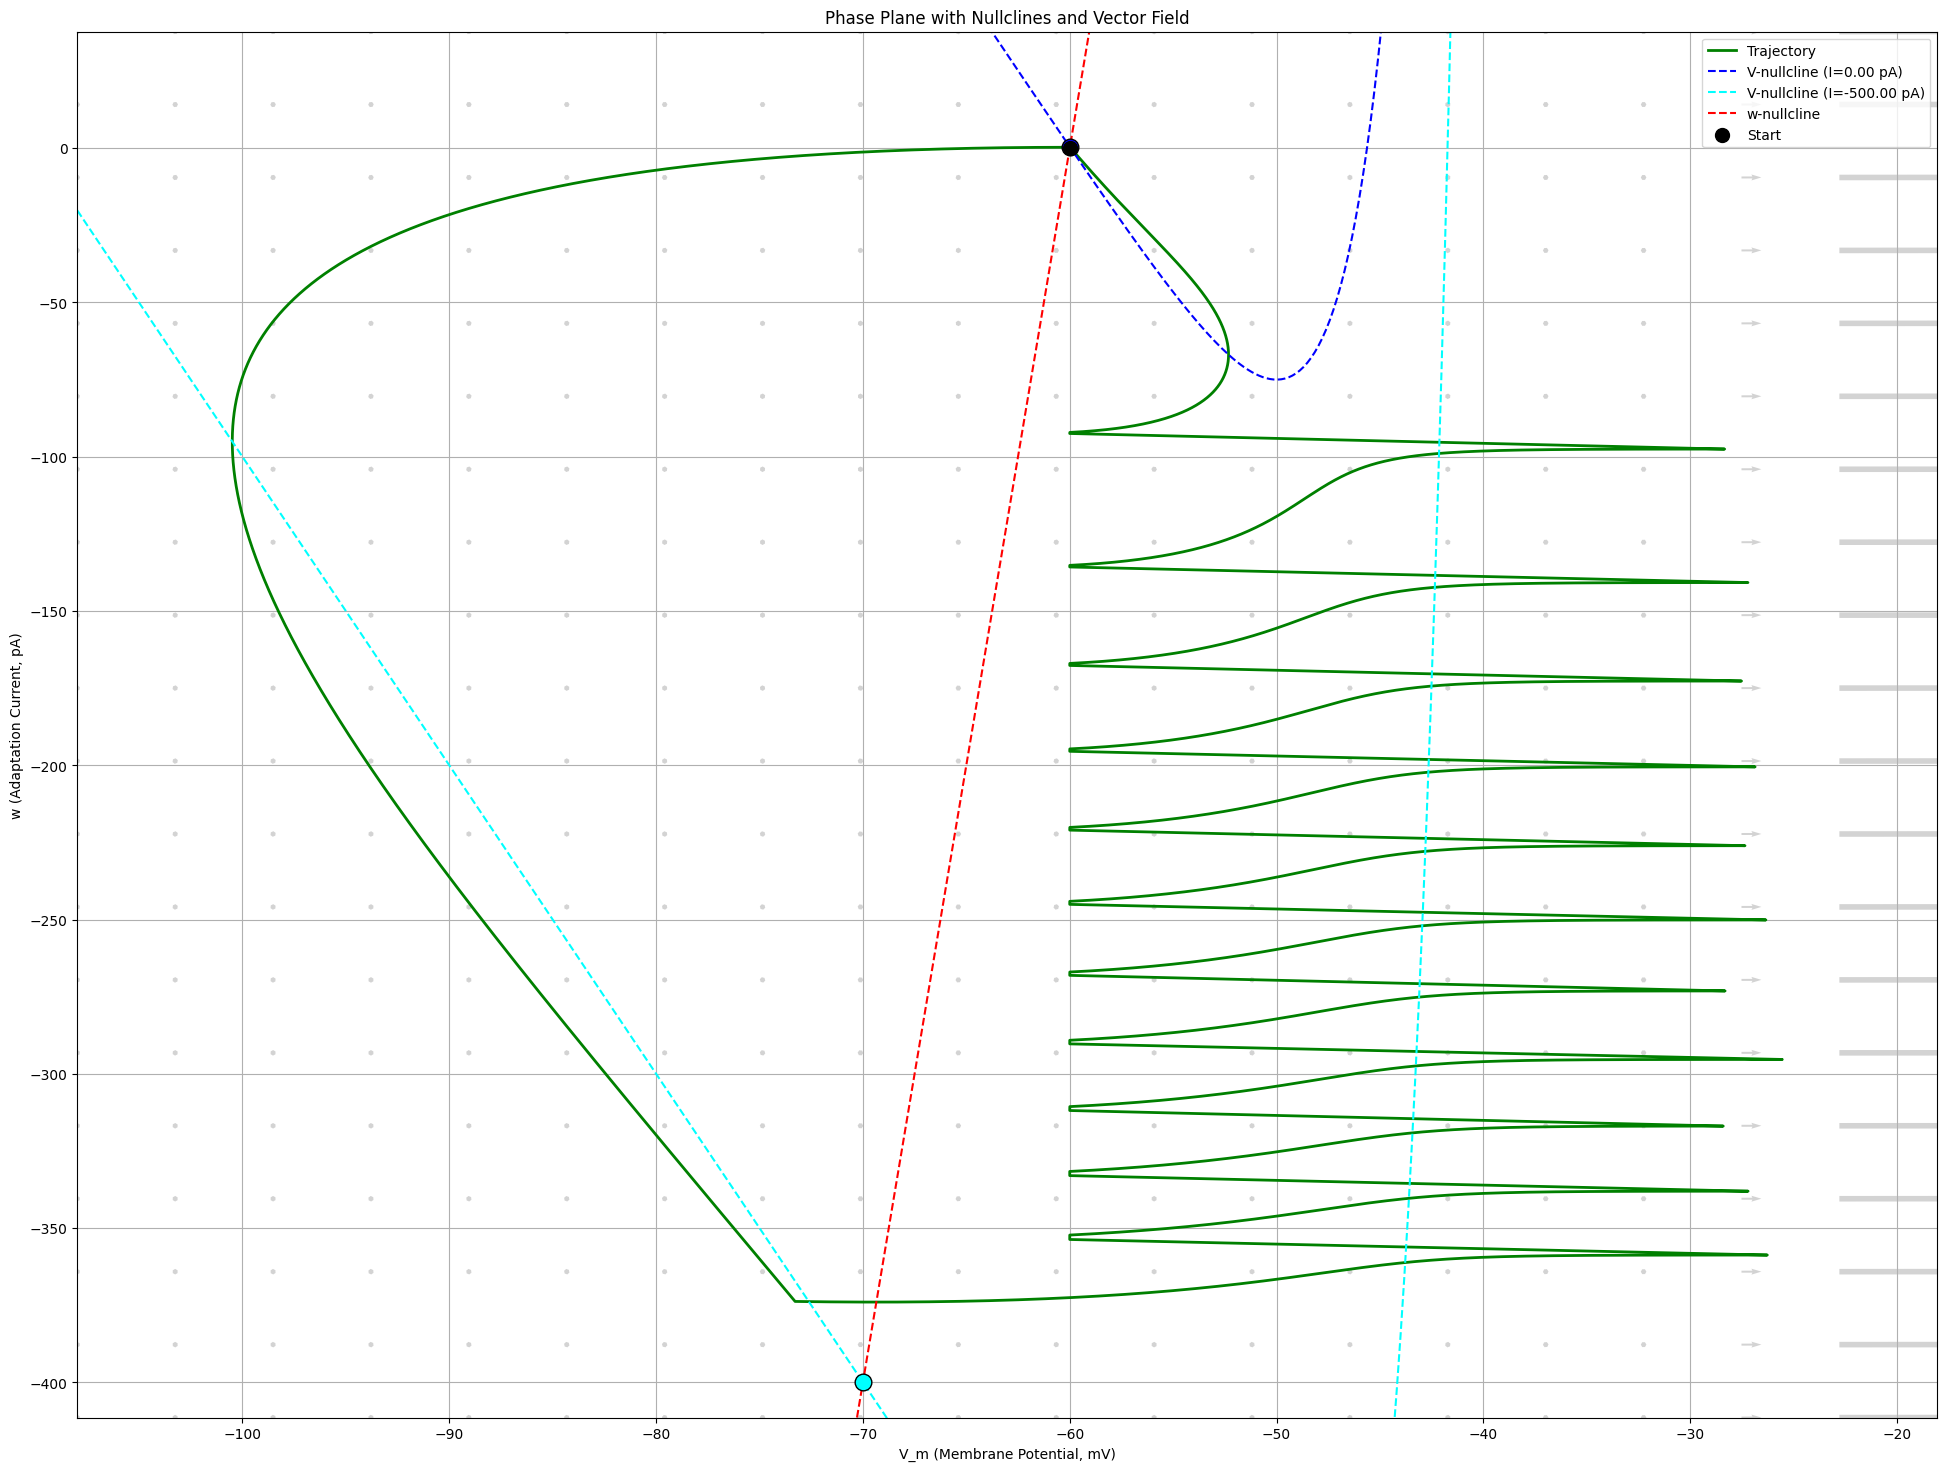

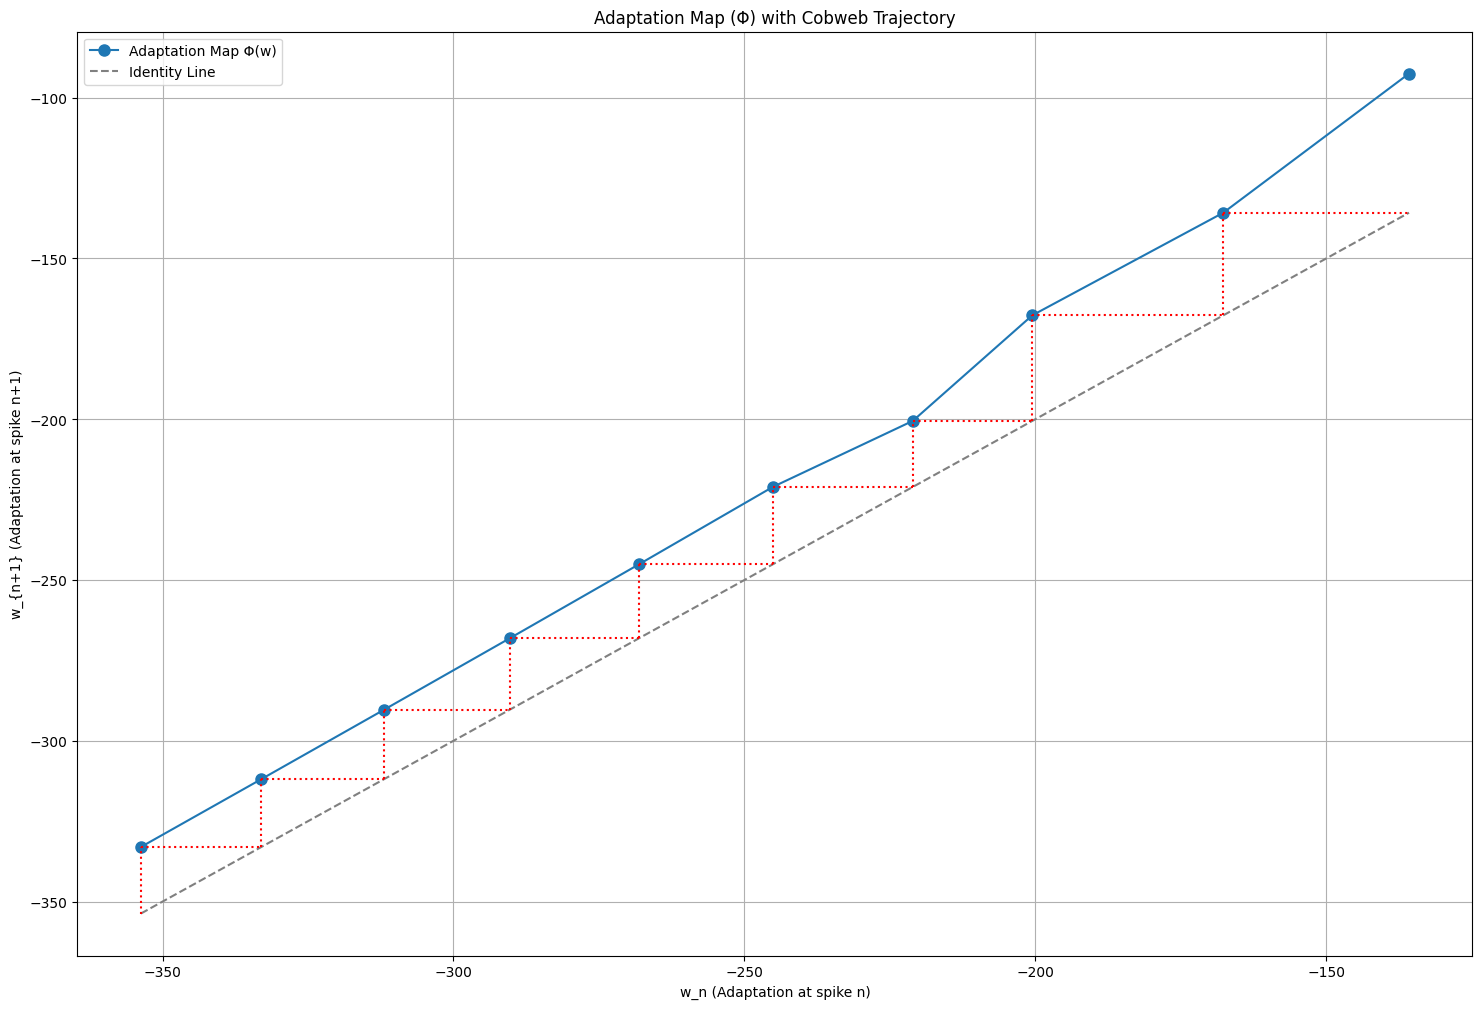

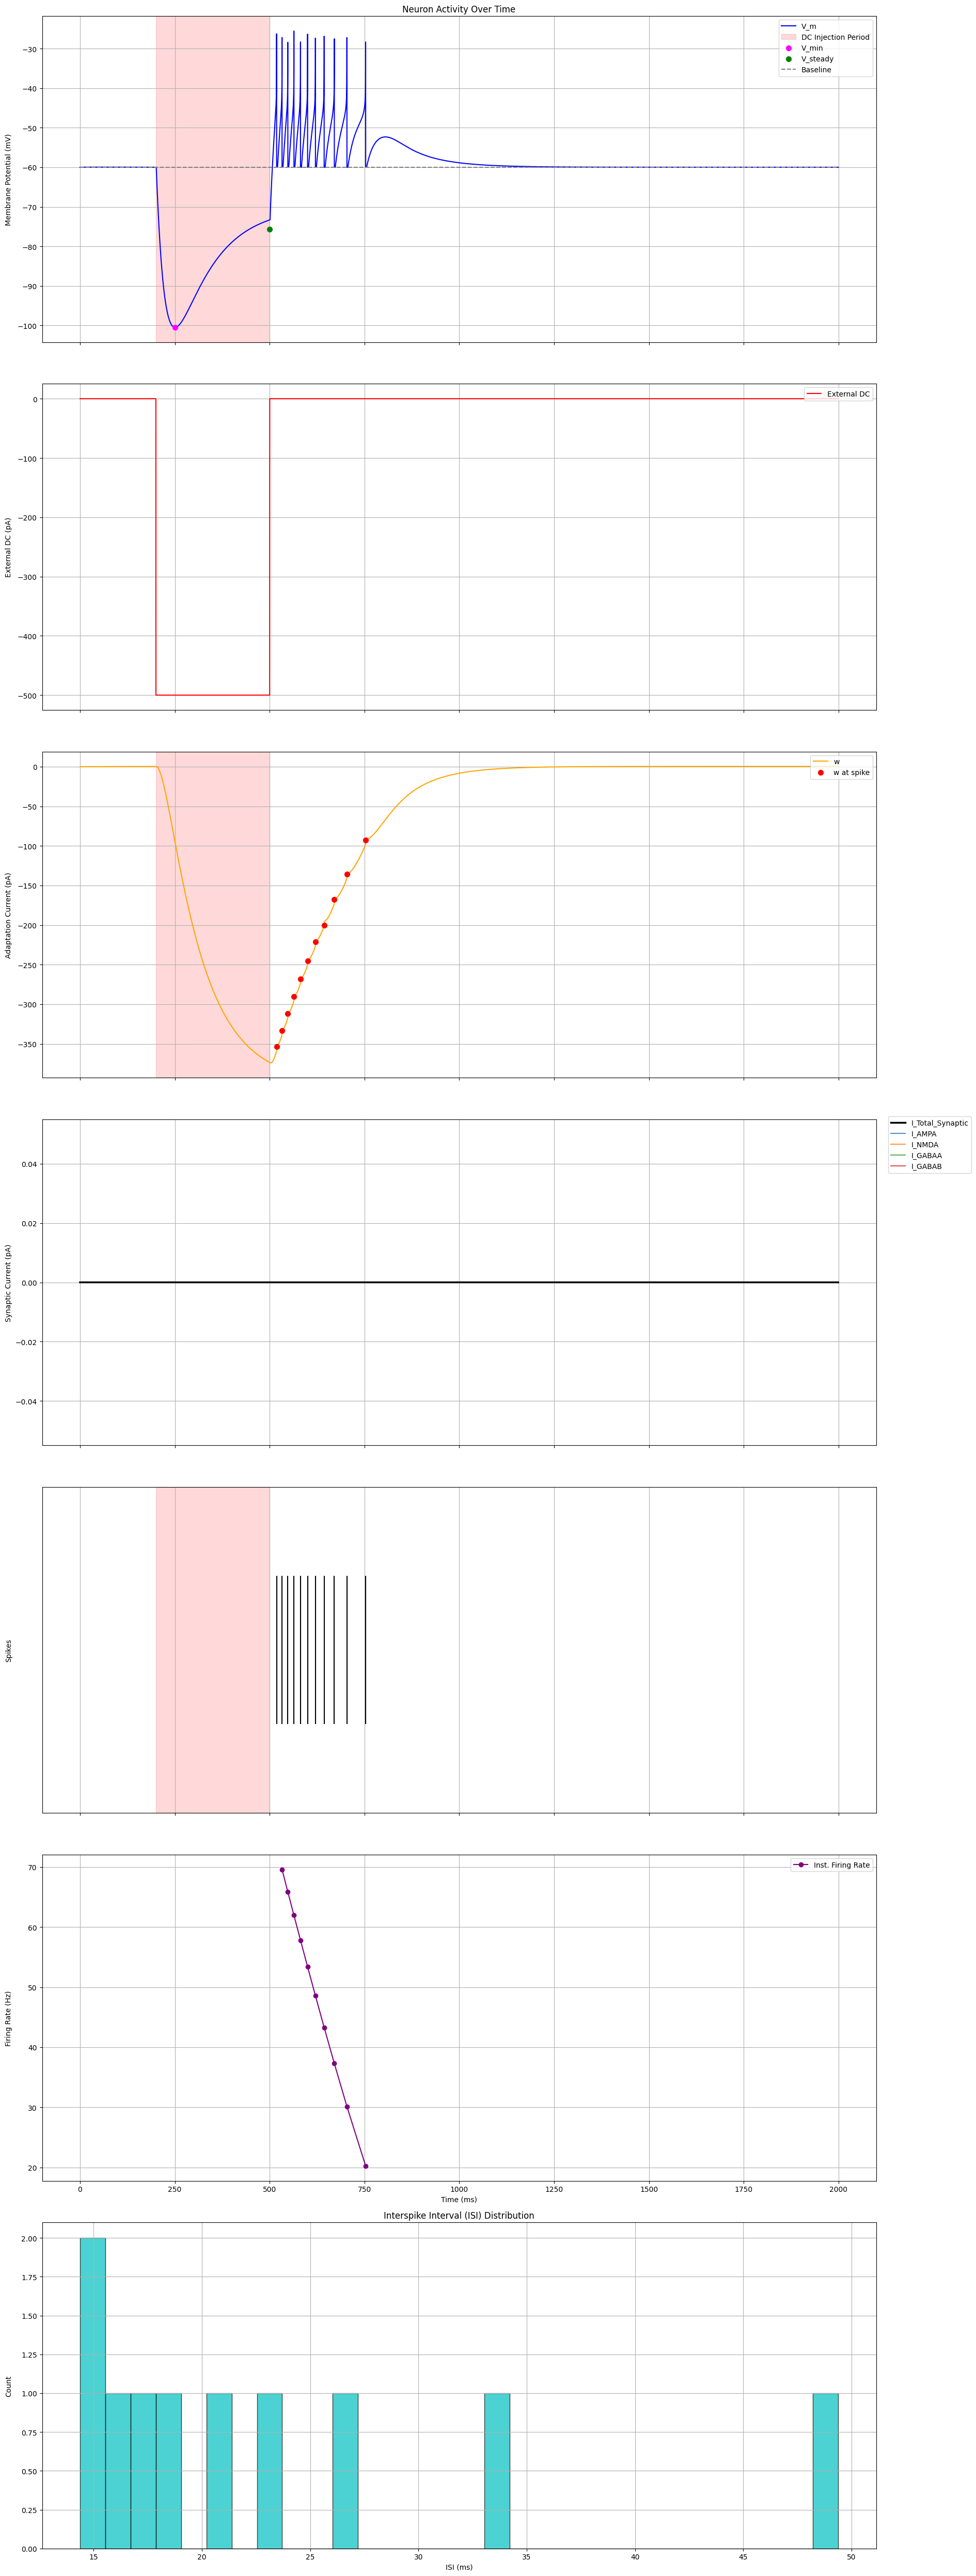

In [1]:
amplitude_dc = -500.0        # pA
start_dc = 200.0             # ms
end_dc = 500.0               # ms
simtime = 2000.0             # ms

params_dict = {
    "C_m": 200.0,            # pF
    "g_L": 10.0,             # nS
    "E_L": -60.0,            # mV 
    "E_AMPA": 0,             # mV 
    "E_GABAA": -80,          # mV
    "E_GABAB": -90,          # mV
    "E_NMDA": 0,             # mV
    "Delta_T": 2.5,          # mV
    "V_th": -50.0,           # mV
    "V_reset": -60.0,        # mV
    "V_peak": 0.0,           # mV
    "t_ref": 2.5,            # ms
    "tau_w": 600.0,          # ms
    "a_param": 40.0,         # nS
    "b_param": 5.0,          # pA
    "tau_decay_AMPA": 5,     # ms
    "tau_rise_AMPA": 0.4,    # ms
    "tau_decay_GABAA": 20,   # ms
    "tau_rise_GABAA": 0.4,   # ms
    "tau_decay_GABAB": 200,  # ms
    "tau_rise_GABAB": 5,     # ms
    "tau_decay_NMDA": 150,   # ms
    "tau_rise_NMDA": 2,      # ms
    "I_e": 0                 # pA
}

import nest
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd
import seaborn as sns
from scipy.optimize import fsolve
import numpy.linalg as LA

nest.ResetKernel()
nest.SetKernelStatus({"resolution": 0.001})
nest.Install("adex_2expnms_gap_rec_module")
nest.Install("adex_2expnms_rec_module")

neuron = nest.Create("adex_2expnms_rec_neuron")
neuron.set(params_dict)

dc = False
pos_dc = False

if amplitude_dc != 0:
    dc = True
    if (amplitude_dc > 0):
        pos_dc = True
    dc_current = nest.Create("dc_generator", params={"start": start_dc, "stop": end_dc, "amplitude": amplitude_dc})
    nest.Connect(dc_current, neuron)

multimeter = nest.Create("multimeter", params={"record_from": ["V_m", "w" , "I_syn_AMPA", "I_syn_NMDA", "I_syn_GABAA", "I_syn_GABAB"], "interval": 0.004})
spikerecorder = nest.Create("spike_recorder")
nest.Connect(multimeter, neuron)
nest.Connect(neuron, spikerecorder)


nest.Simulate(simtime)

data = multimeter.get()
Vms = data["events"]["V_m"]
ws = data["events"]["w"]
I_AMPA = data["events"]["I_syn_AMPA"]
I_NMDA = data["events"]["I_syn_NMDA"]
I_GABAA = data["events"]["I_syn_GABAA"]
I_GABAB = data["events"]["I_syn_GABAB"]
times = data["events"]["times"]
spike_times = spikerecorder.get("events")["times"]

params = nest.GetStatus(neuron)[0]
g_L = params["g_L"]
E_L = params["E_L"]
V_T = params["V_th"]
Delta_T = params["Delta_T"]
a = params["a_param"]
C_m = params["C_m"]
tau_w = params["tau_w"]

def find_equilibrium_function(V, I_inj):
    return (a + g_L) * (V - E_L) - g_L * Delta_T * np.exp((V - V_T) / Delta_T) - I_inj

def calculate_jacobian_and_eigenvalues(V_eq):
    dF_dV = (1 / C_m) * (-g_L + g_L * np.exp((V_eq - V_T) / Delta_T))
    dF_dw = -1 / C_m
    dG_dV = a / tau_w
    dG_dw = -1 / tau_w
    
    jacobian_matrix = np.array([
        [dF_dV, dF_dw],
        [dG_dV, dG_dw]
    ])
    
    eigenvalues = LA.eigvals(jacobian_matrix)
    return jacobian_matrix, eigenvalues

def find_all_equilibria(func, I_inj, v_range=(-90.0, -40.0), step=0.1):
    v_values = np.arange(v_range[0], v_range[1], step)
    func_values = func(v_values, I_inj)
    # Find indices where the function's sign changes, indicating a root
    sign_changes = np.where(np.diff(np.sign(func_values)))[0]
    roots = set()
    for idx in sign_changes:
        # Use the V value before the sign change as an initial guess for fsolve
        guess = v_values[idx]
        root = fsolve(func, guess, args=(I_inj,))[0]
        roots.add(np.round(root, 4))      
    return sorted(list(roots))

if dc and not pos_dc:
    # Sag Voltage Analysis
    dc_idx = (times >= start_dc) & (times <= end_dc)
    V_dc = Vms[dc_idx]
    w_dc = ws[dc_idx]
    T_dc = times[dc_idx]
    baseline_idx = times < start_dc
    V_baseline = np.mean(Vms[baseline_idx])
    V_min = np.min(V_dc)
    min_idx = np.argmin(V_dc)
    T_min = T_dc[min_idx]
    steady_state_idx = (T_dc >= (end_dc - 100))
    V_steady = np.mean(V_dc[steady_state_idx])
    V_sag = V_steady - V_min
    
    end_of_pulse = end_dc
    spike_times_after_pulse = spike_times[spike_times >= end_of_pulse]

    burst_metrics = {}

    if len(spike_times_after_pulse) == 0:
        print("No spikes after DC Current Injection. No rebound burst detected.")
    else:
        # 1. ISI-based Burst Detection
        first_spike_time = spike_times_after_pulse[0]
        burst_metrics['latency_ms'] = first_spike_time - end_of_pulse
        
        isi_threshold = 100.0  # (ms) defines the max ISI to be considered inside a burst
        burst_spike_times = [first_spike_time]
        
        if len(spike_times_after_pulse) > 1:
            post_pulse_isis = np.diff(spike_times_after_pulse)
            for i, isi in enumerate(post_pulse_isis):
                if isi <= isi_threshold:
                    burst_spike_times.append(spike_times_after_pulse[i + 1])
                else:
                    # End of burst detected
                    break
        
        burst_metrics['spike_count'] = len(burst_spike_times)

        # 2. Calculate Richer Metrics
        if burst_metrics['spike_count'] > 1:
            burst_isis = np.diff(burst_spike_times)
            burst_metrics['duration_ms'] = burst_spike_times[-1] - burst_spike_times[0]
            burst_metrics['mean_freq_hz'] = 1000.0 / np.mean(burst_isis)
            burst_metrics['peak_freq_hz'] = 1000.0 / np.min(burst_isis)
            if len(burst_isis) > 1:
                burst_metrics['adaptation_ratio'] = burst_isis[-1] / burst_isis[0]
            else:
                 burst_metrics['adaptation_ratio'] = 1.0
        
        # 3. Print Structured Results
        print("\n--- Rebound Burst Metrics ---")
        print(f"  Latency to first spike: {burst_metrics['latency_ms']:.2f} ms")
        print(f"  Number of spikes in burst: {burst_metrics['spike_count']}")
        if burst_metrics['spike_count'] > 1:
            print(f"  Burst duration: {burst_metrics['duration_ms']:.2f} ms")
            print(f"  Mean intraburst frequency: {burst_metrics['mean_freq_hz']:.2f} Hz")
            print(f"  Peak intraburst frequency: {burst_metrics['peak_freq_hz']:.2f} Hz")
            if 'adaptation_ratio' in burst_metrics:
                print(f"  Adaptation ratio (last/first ISI): {burst_metrics['adaptation_ratio']:.2f}")
        print("---------------------------\n")

# Stable points when there is no input
print("\nAnalyzing case with I = 0 pA:")
I1 = 0.0
equilibrium_points_V = find_all_equilibria(find_equilibrium_function, I1)

if not equilibrium_points_V:
    print("No equilibrium points found.")
else:
    for i, v_eq in enumerate(equilibrium_points_V):
        w_eq = a * (v_eq - E_L)
        jacobian, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq)
        print(f"\nEquilibrium Point {i+1} (I=0 pA):")
        print(f"  V_m = {v_eq:.2f} mV, w = {w_eq:.2f} pA")
        print(f"  Jacobian Matrix:\n{jacobian}")
        print(f"  Eigenvalues: {eigenvalues[0]:.4f}, {eigenvalues[1]:.4f}")
        if np.all(np.real(eigenvalues) < 0):
            print("  Stability: Stable point (sink)")
        elif np.any(np.real(eigenvalues) > 0):
            print("  Stability: Unstable point (saddle or source)")
        else:
            print("  Stability: Marginally stable (center or other)")

# Stable points when there is a dc input
if dc:
    print(f"\nAnalyzing case with I = {amplitude_dc} pA:")
    I2 = amplitude_dc
    equilibrium_points_V_dc = find_all_equilibria(find_equilibrium_function, I2)

    if not equilibrium_points_V_dc:
        print("No equilibrium points found.")
    else:
        for i, v_eq in enumerate(equilibrium_points_V_dc):
            w_eq = a * (v_eq - E_L)
            jacobian, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq)
            print(f"\nEquilibrium Point {i+1} (I={amplitude_dc} pA):")
            print(f"  V_m = {v_eq:.2f} mV, w = {w_eq:.2f} pA")
            print(f"  Jacobian Matrix:\n{jacobian}")
            print(f"  Eigenvalues: {eigenvalues[0]:.4f}, {eigenvalues[1]:.4f}")
            if np.all(np.real(eigenvalues) < 0):
                print("  Stability: Stable point (sink)")
            else:
                print("  Stability: Unstable or Marginally stable")


# Phase Plane Plot
# 1. Define the vector field equations
I_base = params["I_e"]
def V_prime(V, w, I_inj):
    return (1/C_m) * (-g_L * (V - E_L) + g_L * Delta_T * np.exp((V - V_T) / Delta_T) - w + I_inj)

def w_prime(V, w):
    return (1/tau_w) * (a * (V - E_L) - w)

# 2. Set plot limits and create a grid for the vector field
x_min, x_max = Vms.min(), Vms.max()
y_min, y_max = ws.min(), ws.max()
x_padding = (x_max - x_min) * 0.1
y_padding = (y_max - y_min) * 0.1
plot_xlim = [x_min - x_padding, x_max + x_padding]
plot_ylim = [y_min - y_padding, y_max + y_padding]

V_grid, w_grid = np.meshgrid(
    np.linspace(plot_xlim[0], plot_xlim[1], 20),
    np.linspace(plot_ylim[0], plot_ylim[1], 20)
)

# 3. Calculate vector field for the base current case
dV_dt = V_prime(V_grid, w_grid, I_base)
dw_dt = w_prime(V_grid, w_grid)

plt.figure(figsize=(24, 18))

# 4. Plot the vector field
plt.quiver(V_grid, w_grid, dV_dt, dw_dt, color='lightgray', minshaft=2)

# 5. Plot the trajectory and nullclines
V_range = np.linspace(plot_xlim[0], plot_xlim[1], 500)
V_nullcline = -g_L * (V_range - E_L) + g_L * Delta_T * np.exp((V_range - V_T) / Delta_T) + I_base
w_nullcline = a * (V_range - E_L)

plt.plot(Vms, ws, label='Trajectory', color='g', linewidth=2)
plt.plot(V_range, V_nullcline, '--', label=f'V-nullcline (I={I_base:.2f} pA)', color='b')
if dc:
    V_nullcline_dc = -g_L * (V_range - E_L) + g_L * Delta_T * np.exp((V_range - V_T) / Delta_T) + I_base + amplitude_dc
    plt.plot(V_range, V_nullcline_dc, '--', label=f'V-nullcline (I={amplitude_dc:.2f} pA)', color='cyan')
plt.plot(V_range, w_nullcline, '--', label='w-nullcline', color='r')

# 6. Plot the calculated equilibrium points
# (This assumes 'equilibrium_points_V' and 'equilibrium_points_V_dc' from the analysis exist)
for v_eq in equilibrium_points_V:
    w_eq = a * (v_eq - E_L)
    jacobian, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq)
    if np.all(np.real(eigenvalues) < 0): # Stable point
        plt.plot(v_eq, w_eq, 'o', markersize=12, markerfacecolor='blue', markeredgecolor='k')
    else: # Unstable or saddle point
        plt.plot(v_eq, w_eq, 'o', markersize=12, markerfacecolor='none', markeredgecolor='k')

if dc:
    for v_eq in equilibrium_points_V_dc:
        w_eq = a * (v_eq - E_L)
        jacobian, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq)
        if np.all(np.real(eigenvalues) < 0):
            plt.plot(v_eq, w_eq, 'o', markersize=12, markerfacecolor='cyan', markeredgecolor='k')
        else:
            plt.plot(v_eq, w_eq, 'o', markersize=12, markerfacecolor='none', markeredgecolor='k')

# 7. Final plot settings
plt.scatter(Vms[0], ws[0], color='k', s=100, zorder=5, label='Start')
plt.axis([plot_xlim[0], plot_xlim[1], plot_ylim[0], plot_ylim[1]])
plt.xlabel("V_m (Membrane Potential, mV)")
plt.ylabel("w (Adaptation Current, pA)")
plt.title("Phase Plane with Nullclines and Vector Field")
plt.legend()
plt.grid(True)
plt.show()


# Adaptation Map (Φ) Analysis
w_at_spikes = [ws[np.argmin(np.abs(times - t))] for t in spike_times]
w_next = w_at_spikes[1:]
w_current = w_at_spikes[:-1]

plt.figure(figsize=(18, 12))

# 1. Plot the adaptation map and identity line
plt.plot(w_current, w_next, 'o-', markersize=8, label="Adaptation Map Φ(w)")
plt.plot(w_current, w_current, '--', label="Identity Line", color='gray')

# 2. Add the cobweb plot to show trajectory
if len(w_current) > 0:
    for i in range(len(w_current) - 1):
        # Draw vertical line from identity to function
        plt.plot([w_current[i], w_current[i]], [w_current[i], w_next[i]], color='r', linestyle=':')
        # Draw horizontal line from function to identity
        plt.plot([w_current[i], w_next[i]], [w_next[i], w_next[i]], color='r', linestyle=':')

# 3. Final plot settings
plt.xlabel("w_n (Adaptation at spike n)")
plt.ylabel("w_{n+1} (Adaptation at spike n+1)")
plt.title("Adaptation Map (Φ) with Cobweb Trajectory")
plt.legend()
plt.grid(True)
plt.show()






fig = plt.figure(figsize=(20, 50)) # Increased figure height for the new plot

# --- 1. Membrane Potential Plot ---
ax1 = plt.subplot(7, 1, 1)
ax1.plot(times, Vms, label="V_m", color='b')
ax1.set_ylabel("Membrane Potential (mV)")
ax1.set_title("Neuron Activity Over Time")
ax1.grid(True)
if dc:
    ax1.axvspan(start_dc, end_dc, color='red', alpha=0.15, label='DC Injection Period')
    if not pos_dc:
        ax1.scatter(T_min, V_min, color='magenta', zorder=5, s=50, label='V_min')
        ax1.scatter(T_dc[-1], V_steady, color='green', zorder=5, s=50, label='V_steady')
        ax1.hlines(V_baseline, times[0], times[-1], colors='gray', linestyles='--', label='Baseline')
ax1.legend(loc='upper right')

# --- 2. External DC Current Plot (NEW) ---
ax2 = plt.subplot(7, 1, 2, sharex=ax1)
dc_current_trace = np.zeros_like(times)
if dc:
    dc_indices = (times >= start_dc) & (times <= end_dc)
    dc_current_trace[dc_indices] = amplitude_dc
ax2.plot(times, dc_current_trace, label="External DC", color='r')
ax2.set_ylabel("External DC (pA)")
ax2.legend(loc='upper right')
ax2.grid(True)

# --- 3. Adaptation Current Plot ---
ax3 = plt.subplot(7, 1, 3, sharex=ax1)
ax3.plot(times, ws, label="w", color='orange')
if len(spike_times) > 0:
    w_at_spikes = [ws[np.argmin(np.abs(times - t))] for t in spike_times]
    ax3.scatter(spike_times, w_at_spikes, color='red', zorder=5, s=50, label='w at spike')
if dc:
    ax3.axvspan(start_dc, end_dc, color='red', alpha=0.15)
ax3.set_ylabel("Adaptation Current (pA)")
ax3.legend(loc='upper right')
ax3.grid(True)

# --- 4. Synaptic Currents Plot ---
ax4 = plt.subplot(7, 1, 4, sharex=ax1)
I_total = I_AMPA + I_NMDA + I_GABAA + I_GABAB
ax4.plot(times, I_total, label="I_Total_Synaptic", color='k', linewidth=2.5, zorder=10)
ax4.plot(times, I_AMPA, label="I_AMPA", alpha=0.8)
ax4.plot(times, I_NMDA, label="I_NMDA", alpha=0.8)
ax4.plot(times, I_GABAA, label="I_GABAA", alpha=0.8)
ax4.plot(times, I_GABAB, label="I_GABAB", alpha=0.8)
ax4.set_ylabel("Synaptic Current (pA)")
ax4.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02))
ax4.grid(True)

# --- 5. Spike Raster Plot ---
ax5 = plt.subplot(7, 1, 5, sharex=ax1)
ax5.eventplot(spike_times, lineoffsets=1, linelengths=1.0, colors='k')
if dc:
    ax5.axvspan(start_dc, end_dc, color='red', alpha=0.15)
ax5.set_yticks([])
ax5.set_ylabel("Spikes")
ax5.grid(True, axis='x')

# --- 6. Instantaneous Firing Rate Plot ---
ax6 = plt.subplot(7, 1, 6, sharex=ax1)
if len(spike_times) > 1:
    isi = np.diff(spike_times)
    inst_rate = 1000.0 / isi
    ax6.plot(spike_times[1:], inst_rate, 'o-', color='purple', label='Inst. Firing Rate')
else:
    ax6.text(0.5, 0.5, 'Not enough spikes for Firing Rate',
             horizontalalignment='center', verticalalignment='center', transform=ax6.transAxes)
ax6.set_ylabel("Firing Rate (Hz)")
ax6.legend(loc='upper right')
ax6.grid(True)
ax6.set_xlabel("Time (ms)")

# --- 7. ISI Histogram Plot ---
ax7 = plt.subplot(7, 1, 7)
if len(spike_times) > 1:
    isi = np.diff(spike_times)
    ax7.hist(isi, bins=30, color='c', edgecolor='k', alpha=0.7)
    ax7.set_title("Interspike Interval (ISI) Distribution")
    ax7.set_xlabel("ISI (ms)")
    ax7.set_ylabel("Count")
    ax7.grid(True)
else:
    ax7.text(0.5, 0.5, 'Not enough spikes for ISI Histogram',
             horizontalalignment='center', verticalalignment='center', transform=ax7.transAxes)
    ax7.set_title("ISI Distribution")
    ax7.grid(True)

# Remove redundant x-axis labels
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax4.get_xticklabels(), visible=False)
plt.setp(ax5.get_xticklabels(), visible=False)

fig.align_ylabels()
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()


